<a href="https://colab.research.google.com/github/tomasndlate/ai-learning/blob/main/deep_learning_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning - Assignment 1

## Task 1 - Implement Logistic Regression

Classification problem - output the probability (0-1) how likely the output is positive.

Goal is to find a **dividing line** (decision boundary) between classes:
- $ z(x) = (w \times x) + b $, where:
    - $ w $ - weights
    - $ b $ - bias

After finding the **dividing line**, it is needed to apply an **activation function** to convert to a function with $ y $ between 0 and 1.

This way it is possible to predict if an input $ x $ IS (1) or IS NOT (0) a certain class.

Linear Regression -> Logistic Function:
- from -> $ z(x) = (w \times x) + b $
- to -> $ f(z) = \frac{1}{1 + e^{-z}} $

Logistic Regression = Single-Node Neural Network

Import needed libraries:

In [16]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np

In [17]:
# Display plots inline
%matplotlib inline

*This next steps I defined messages that later will redefine inside the Logistic Rgression class - it is easier to follow thinking as a step by step:*

#### Weight Initialisation

Initialise a starting vector of default weights (w) and the Bias (b).


In [18]:
def init_weights_and_bias(num_features):
  w = np.zeros((1, num_features))
  b = 0
  return w, b

#### Sigmoid Function

Probability of data being a specific class (return values between 0 and 1).

Formula -> $ f(z) = \frac{1}{1 + e^{-z}} $

In [19]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

#### Forward Propagation

Calculate linear combination and then pass the result to the sigmoid function to calculate the class probability

$ z(x) = (w \times x) + b $, and use this result in sigmoid function to get a probability 0 to 1

In [20]:
def forward_propagation(w, b, X):
  z = np.dot(w, X) + b
  f = sigmoid(z)
  return f

#### Cost Function - Stochastic Gradient Decent

It compares model predicted label with the true label. Returns how wrong model was.

In [21]:
def cost_function(y, y_pred):
  m = y.shape[1]
  return -(1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

#### Backward Propagation

Calculate the gradients (derivatives). It indicate s the direction and magnitude to reduce error rate

- Weight Gradient: $ dw = \frac{1}{m} X^{T} (A - T) $

- Bias Gradient: $ dw = \frac{1}{m} \sum{(A - T)}  $

In [22]:
def backward_propagation(y, y_pred, X):
  m = y.shape[0]
  dw = (1 / m) * np.dot(X.T, (y_pred - y))
  db = (1 / m) * np.sum(y_pred - y)
  return dw, db

#### Update Parameters

Based on gradient updates the current parameters

In [23]:
def update_parameters(w, b, dw, db, learning_rate):
  w = w - learning_rate * dw
  b = b - learning_rate * db
  return w, b

#### Logistic Regression Model from scratch

In [84]:
class LogisticRegressionScratch:

  def __init__(self):
    self._w = None
    self._b = None

  ## Public methods:

  def train(self, X, y, num_iterations, learning_rate):
    # m - number of samples
    # n - number of features
    m, n = X.shape

    y = y.reshape(-1, 1)

    # initiate weights and bias
    self._w = np.zeros((n, 1))
    self._b = 0

    costs = []
    for i in range(num_iterations):
      y_pred = self.__forward_propagation(X)

      # Cost calculation every 100 iterations
      if i % 100 == 0:
        costs.append(self.__cost_function(y, y_pred))

      dw, db = self.__backward_propagation(y, y_pred, X)

      self.__update_parameters(dw, db, learning_rate)

    print(f"Costs: {costs}")

  def predict(self, X):
    y_pred = self.__forward_propagation(X)
    return (y_pred >= 0.5).astype(int)

  ## Private methods:

  def __forward_propagation(self, X):

    def linear_combination(X):
      return np.dot(X, self._w) + self._b

    def sigmoid(z):
      return 1.0 / (1.0 + np.exp(-z))

    z = linear_combination(X)
    f = sigmoid(z)
    return f

  def __cost_function(self, y, y_pred):
    m = y.shape[0]
    return -(1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

  def __backward_propagation(self, y, y_pred, X):
    m = y.shape[0]
    error = y_pred - y
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db

  def __update_parameters(self, dw, db, learning_rate):
    self._w -= learning_rate * dw
    self._b -= learning_rate * db


## Task 2 - Testing on Datasets

#### Load Small Datasets

In [50]:
datasets_folder_path = "/content/drive/MyDrive/deep_learning/"

##### Dataset 1 - Blobs 3D

In [52]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv(f"{datasets_folder_path}blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [53]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


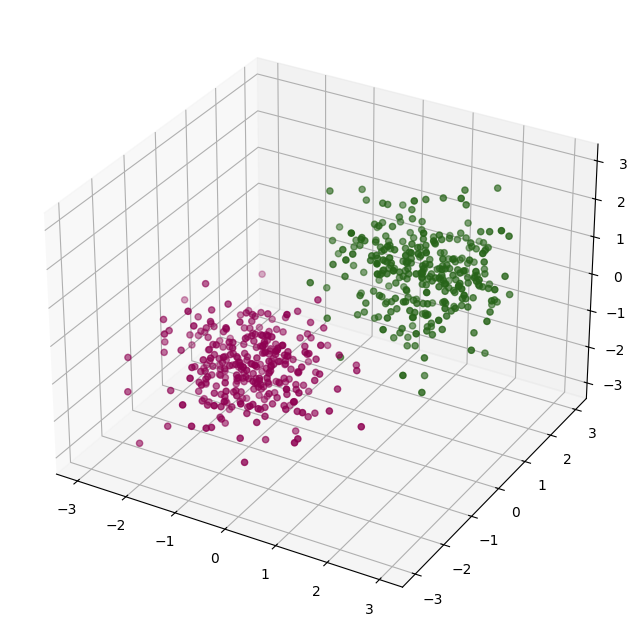

In [54]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

##### Split, Train, Test - Dataset 1

In [55]:
# seed to repeat same random every time I run
np.random.seed(42)

Split dataset:

In [65]:
indices = np.arange(X1.shape[0])
np.random.shuffle(indices)

train_end_index = int(0.7 * len(X1))
val_end_index = int(0.85 * len(X1))

train_idx = indices[:train_end_index]
val_idx = indices[train_end_index:val_end_index]
test_idx = indices[val_end_index:]

X_train, y_train = X1[train_idx], y1[train_idx]
X_val, y_val = X1[val_idx], y1[val_idx]
X_test, y_test = X1[test_idx], y1[test_idx]

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (420, 3)
Validation: (90, 3)
Test: (90, 3)


Train:

In [66]:
model = LogisticRegressionScratch()

model.train(X_train, y_train, num_iterations=1000, learning_rate=0.1)

test_predictions = model.predict(X_test)
accuracy = np.mean(test_predictions.flatten() == y_test.flatten())

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Costs: [np.float64(0.6931471805599453), np.float64(0.06307806181739872), np.float64(0.04244912274816792), np.float64(0.03448814306490307), np.float64(0.030112875502729095), np.float64(0.027293423778870993), np.float64(0.02530212317653918), np.float64(0.023809052258654057), np.float64(0.02264136887888951), np.float64(0.021699115781860023)]
Final Test Accuracy: 100.00%


Test and plot:

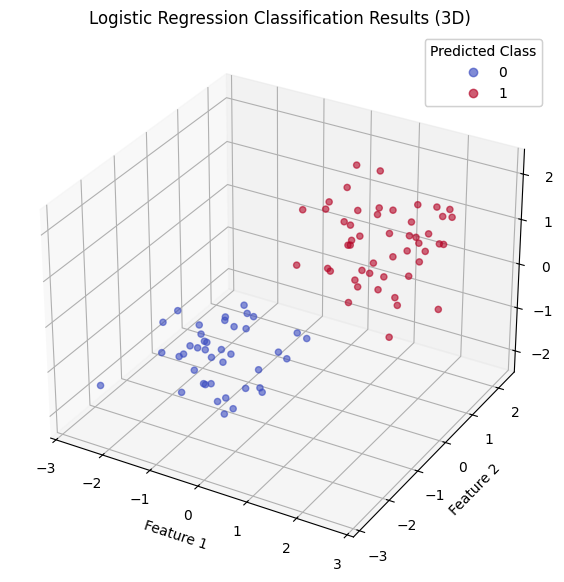

In [61]:
# Predict test dataset
y_pred_total = model.predict(X_test)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(X_test[:,0], X_test[:,1], X_test[:,2], c=y_pred_total.flatten(), cmap="coolwarm", alpha=0.6)

ax.set_title("Logistic Regression Classification Results (3D)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Predicted Class")
ax.add_artist(legend1)

plt.show()

##### Dataset 2 - Circles 2D

In [67]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(f"{datasets_folder_path}circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [68]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


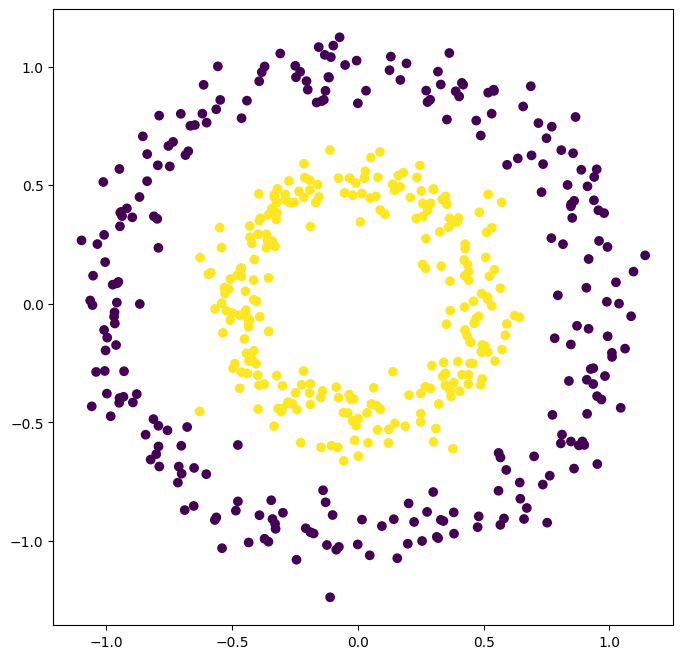

In [69]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

##### Split, Train, Test - Dataset 2

Split dataset:

In [74]:
indices2 = np.arange(X2.shape[0])
np.random.shuffle(indices2)

train_end_index = int(0.7 * len(X2))
val_end_index = int(0.85 * len(X2))

X2_train, y2_train = X2[indices2[:train_end_index]], y2[indices2[:train_end_index]]
X2_val, y2_val = X2[indices2[train_end_index:val_end_index]], y2[indices2[train_end_index:val_end_index]]
X2_test, y2_test = X2[indices2[val_end_index:]], y2[indices2[val_end_index:]]

print(f"Train: {X2_train.shape}")
print(f"Validation: {X2_val.shape}")
print(f"Test: {X2_test.shape}")

Train: (350, 2)
Validation: (75, 2)
Test: (75, 2)


Train:

In [75]:
model2 = LogisticRegressionScratch()

model2.train(X2_train, y2_train, num_iterations=1000, learning_rate=0.1)

Costs: [np.float64(0.6931471805599453), np.float64(0.6918184873027384), np.float64(0.6915449009908674), np.float64(0.6914857249700511), np.float64(0.6914728727321828), np.float64(0.6914700766350942), np.float64(0.6914694676969287), np.float64(0.6914693349905289), np.float64(0.6914693060552952), np.float64(0.6914692997438087)]


Test and plot:

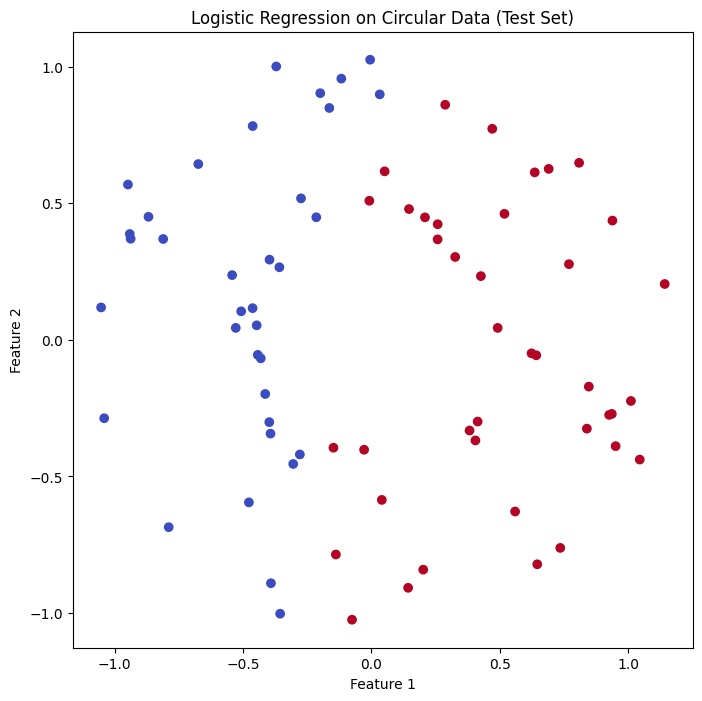

In [77]:
y2_pred = model2.predict(X2_test)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2_test[:,0], X2_test[:,1], c=y2_pred.flatten(), cmap="coolwarm")

ax.set_title("Logistic Regression on Circular Data (Test Set)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

**Observation**: this accuracy is really low compared with the dataset 1 because the logistic regression is limited to linear decision boundaries. In this dataset 2 the data is circular (non-linear).

I know that as mentioned in lectures, there are work around for this type of data, such as transform to the power of 2, but I don't think is the goal of the assignment.

## Task 3 - Implement and Test a Shallow Neural Network

In [110]:
class ShallowNeuralNetworkScratch:

    def __init__(self, num_hidden):
        self.num_hidden = num_hidden
        self._w_hidden, self._b_hidden = None, None
        self._w_output, self._b_output = None, None

    ## Public methods:

    def train(self, X, y, num_iterations, learning_rate):
        m, num_hidden = X.shape
        y = y.reshape(-1, 1)

        # 1. Initialise with random weights
        self._w_hidden = np.random.randn(num_hidden, self.num_hidden) * 0.01
        self._b_hidden = np.zeros((1, self.num_hidden))
        self._w_output = np.random.randn(self.num_hidden, 1) * 0.01
        self._b_output = np.zeros((1, 1))

        costs = []
        for i in range(num_iterations):

            y_hidden, y_output = self.__forward_propagation(X)

            dw_hidden, db_hidden, dw_output, db_output = self.__backward_propagation(X, y, y_hidden, y_output)

            self.__update_parameters(dw_hidden, db_hidden, dw_output, db_output, learning_rate)

            # Cost calculation every 1000 iterations
            if i % 1000 == 0:
                cost = -(1/m) * np.sum(y * np.log(y_output) + (1-y) * np.log(1 - y_output))
                costs.append(cost)

        print(f"Costs: {costs}")

    def predict(self, X):
        _, y_pred_output = self.__forward_propagation(X)
        return (y_pred_output >= 0.5).astype(int)

    ## Private methods:

    def __forward_propagation(self, X):

        def linear_combination(X, w, b):
          return np.dot(X, w) + b

        def sigmoid(z):
          return 1.0 / (1.0 + np.exp(-z))

        def tanh(z):
          return np.tanh(z)

        z_hidden = linear_combination(X, self._w_hidden, self._b_hidden)
        f_hidden = tanh(z_hidden)

        z_output = linear_combination(f_hidden, self._w_output, self._b_output)
        f_output = sigmoid(z_output)

        return f_hidden, f_output

    def __backward_propagation(self, X, y, y_hidden, y_output):
      m = y.shape[0]

      # output layer
      error_output = y_output - y
      dw_output = (1 / m) * np.dot(y_hidden.T, error_output)
      db_output = (1 / m) * np.sum(error_output, axis=0, keepdims=True)

      # hidden
      error_hidden = np.dot(error_output, self._w_output.T) * (1 - np.power(y_hidden, 2))
      dw_hidden = (1 / m) * np.dot(X.T, error_hidden)
      db_hidden = (1 / m) * np.sum(error_hidden, axis=0, keepdims=True)

      return dw_hidden, db_hidden, dw_output, db_output

    def __update_parameters(self, dw_hidden, db_hidden, dw_output, db_output, learning_rate):
        self._w_hidden -= learning_rate * dw_hidden
        self._b_hidden -= learning_rate * db_hidden
        self._w_output -= learning_rate * dw_output
        self._b_output -= learning_rate * db_output

##### Train and Test Dataset 1

In [111]:
neural_network_model = ShallowNeuralNetworkScratch(num_hidden=4)
neural_network_model.train(X_train, y_train, num_iterations=2000, learning_rate=0.1)

# Evaluation
y_preds = neural_network_model.predict(X_test)
y_preds_acc = np.mean(y_preds.flatten() == y_test.flatten())

print(f"Dataset 1 - accuracy: {y_preds_acc * 100:.2f}%")

Costs: [np.float64(0.6932095368290112), np.float64(0.014724098396906169)]
Dataset 1 - accuracy: 100.00%


##### Train and Test Dataset 2

In [112]:
hidden_sizes = [2, 4, 10, 20]

# Try different hidden layer sizes
for size in hidden_sizes:
    print(f"Model with {size} hidden nodes")
    neural_network_model = ShallowNeuralNetworkScratch(num_hidden=size)
    neural_network_model.train(X2_train, y2_train, num_iterations=5000, learning_rate=0.5)

    y_preds = neural_network_model.predict(X2_val)
    y_preds_acc = np.mean(y_preds.flatten() == y2_val.flatten())
    print(f"Validation Accuracy: {y_preds_acc * 100:.2f}%")

Model with 2 hidden nodes
Costs: [np.float64(0.6931459387813828), np.float64(0.5372586109871474), np.float64(0.4412450961192853), np.float64(0.42967547506232107), np.float64(0.4246959909811208)]
Validation Accuracy: 74.67%
Model with 4 hidden nodes
Costs: [np.float64(0.6931474642159963), np.float64(0.6116871697400855), np.float64(0.08488784220403446), np.float64(0.05092913665721643), np.float64(0.03735164407359305)]
Validation Accuracy: 98.67%
Model with 10 hidden nodes
Costs: [np.float64(0.6931417624871847), np.float64(0.6335877822356364), np.float64(0.07678566252878155), np.float64(0.047776317146598454), np.float64(0.03672373695591724)]
Validation Accuracy: 100.00%
Model with 20 hidden nodes
Costs: [np.float64(0.6931411366346475), np.float64(0.6911284127852839), np.float64(0.1522976743147246), np.float64(0.05035901718025049), np.float64(0.03481361249552487)]
Validation Accuracy: 100.00%


## Task 4 - Tackle a Challenging Task

I'll choose "A" and "B". When I arrive to this task it was too late to send email to teacher.

#### Load EMNIST Letters

In [113]:
data = np.load(f"{datasets_folder_path}emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [114]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


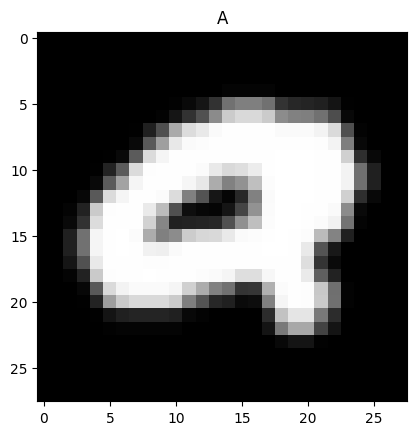

In [115]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))
plt.show()

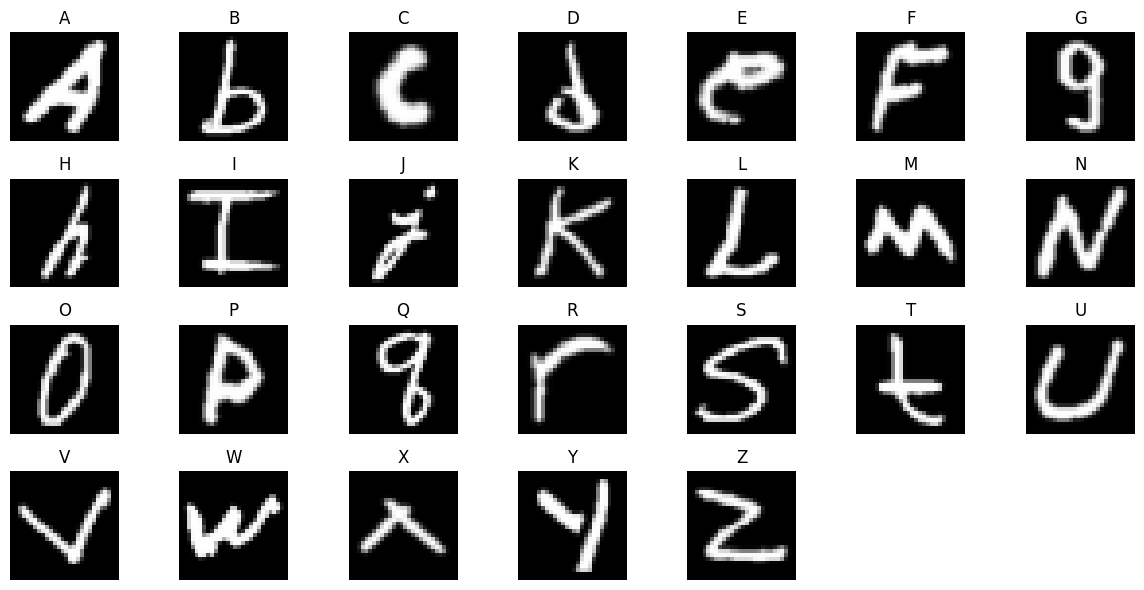

In [116]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    # Find first index of this class
    idx = np.where(y_data == cls)[0][n]

    plt.subplot(4, 7, i + 1)
    plt.imshow(x_data[idx].squeeze(), cmap="gray")
    plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
    plt.axis("off")

plt.tight_layout()
plt.show()

In [117]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 1  # Notice to late to send email to teacher
c2 = 2  # Notice to late to send email to teacher

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [118]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))

    for i in range(48):
        idx = n + i

        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

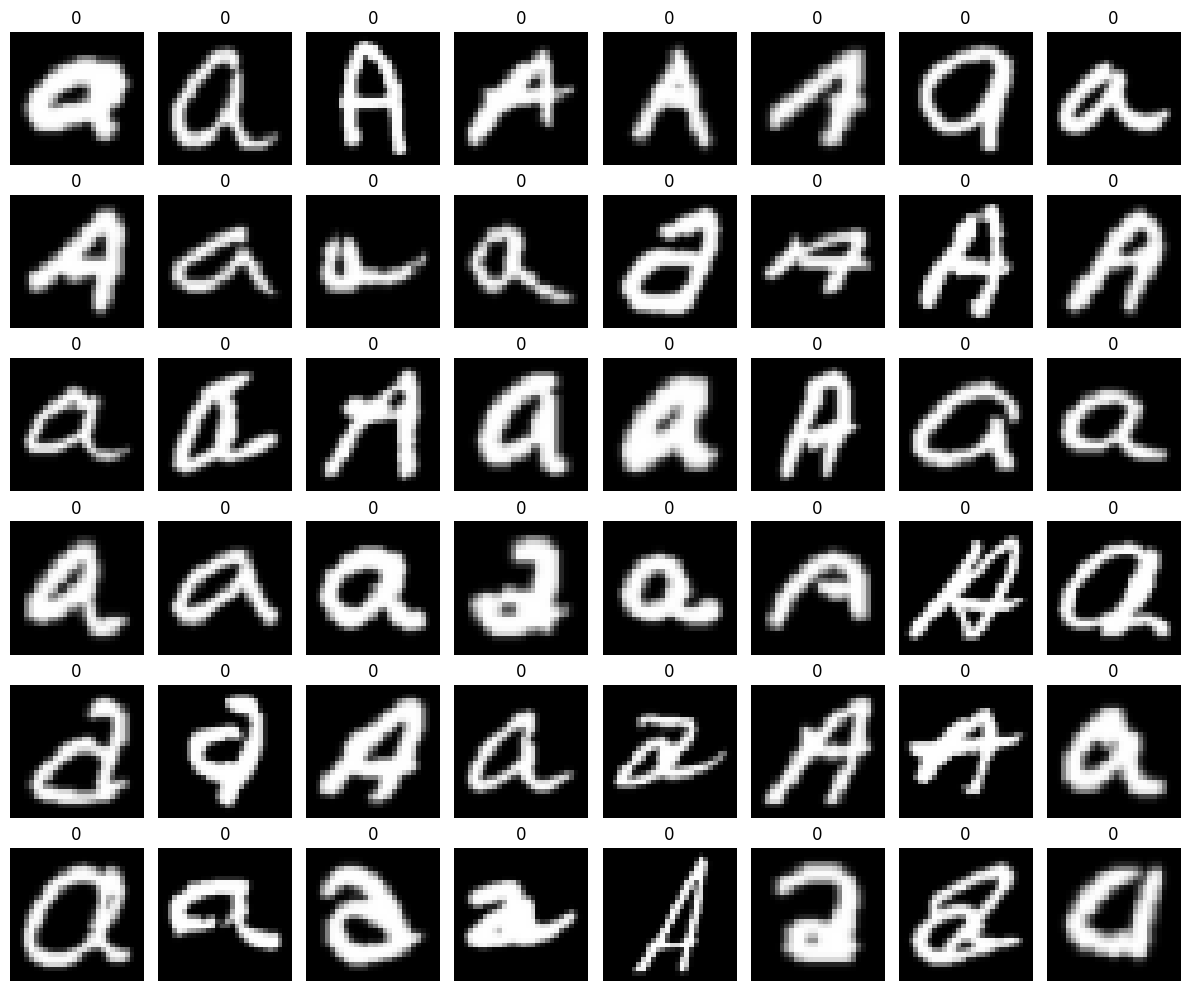

In [119]:
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

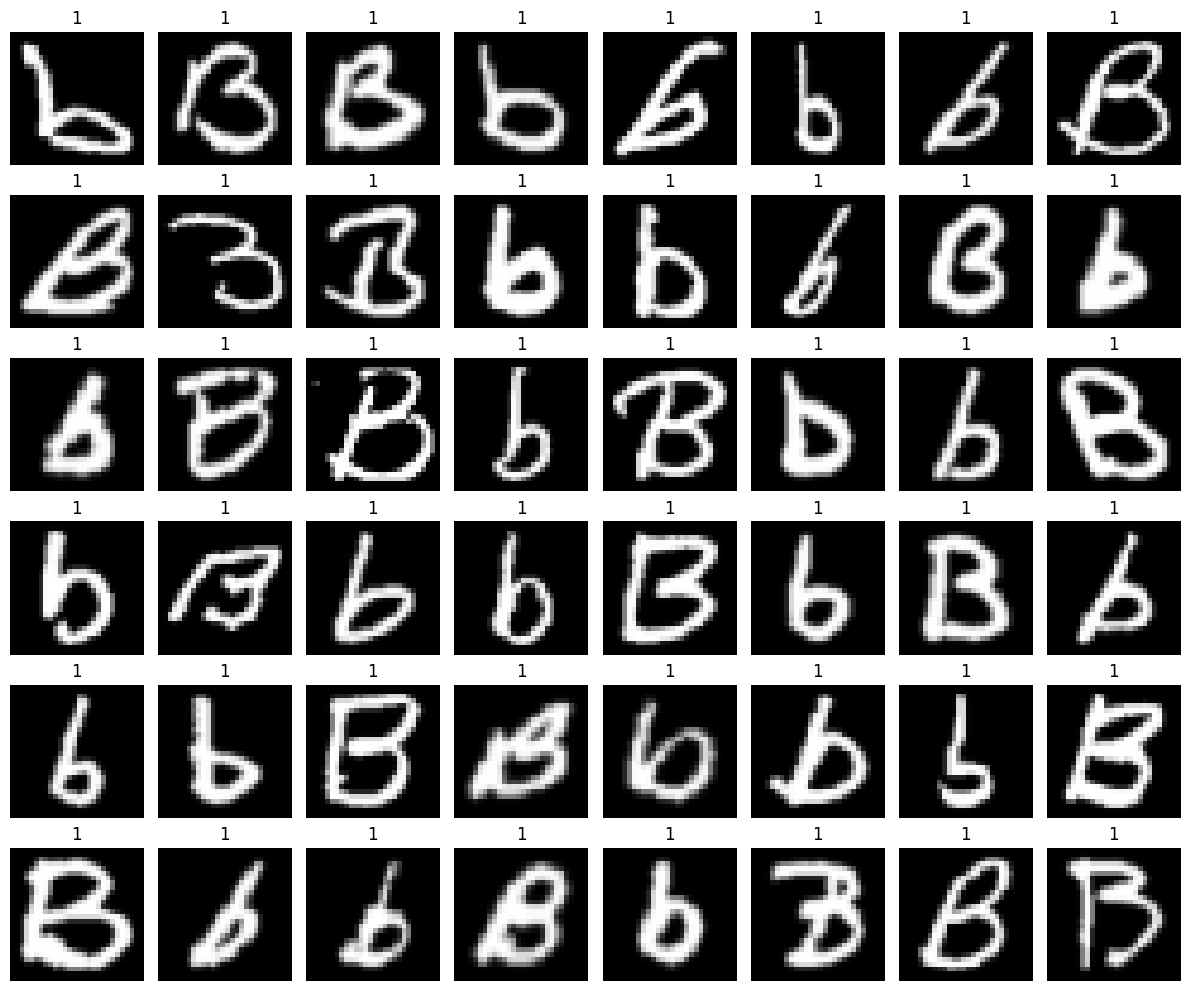

In [120]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

##### Pre-process and Split data

In [126]:
X_flat = x_binary.reshape(len(x_binary), -1)
Y_flat = y_binary.reshape(-1, 1)

# Randomise data for datasets
np.random.seed(42)
p = np.random.permutation(len(X_flat))
X_shuffled, Y_shuffled = X_flat[p], Y_flat[p]

# Split datasets in train 70%, validation 15%, and test 15%
X_train, X_val, X_test = np.split(X_shuffled, [int(.7*len(X_shuffled)), int(.85*len(X_shuffled))])
y_train, y_val, y_test = np.split(Y_shuffled, [int(.7*len(Y_shuffled)), int(.85*len(Y_shuffled))])

print(f"Train {X_train.shape}")
print(f"Validation {X_val.shape}")
print(f"Test {X_test.shape}")

Train (4620, 784)
Validation (990, 784)
Test (990, 784)


Initialise and Train:

In [123]:
neural_network_model = ShallowNeuralNetworkScratch(num_hidden=32)

neural_network_model.train(X_train, y_train, num_iterations=3000, learning_rate=0.1)

Costs: [np.float64(0.6940263776053346), np.float64(0.08719205490905879), np.float64(0.047689818602071346)]


Test:

In [125]:
y_pred_test = neural_network_model.predict(X_test)

test_accuracy = np.mean(y_pred_test.flatten() == y_test.flatten())

print(f"Neural Network Accuracy: {test_accuracy * 100:.2f}%")

Neural Network Accuracy: 97.37%


## Task 5 - Deep Learning Enhancements

*No time to finish*

## Resources Used

- [Logistic Regression From Scratch in Python (Mathematical)](https://youtu.be/S6iuhdYsGC8?si=h1A8BCT3nPreHwj_) - explain all maths behind logistic regression algorithm

- [Neural Network from Scratch | Mathematics & Python](https://youtu.be/pauPCy_s0Ok?si=ABtqppnJDxMaiGgb) - explain maths behind neural networks from scratch